# Multivariate inference: 2D harmonic-oscillator analogue

Following the R vignette `multivariate_analysis`, we estimate the dynamics of the second component $x_2$ in the system

$$
f(x) = (x_2,\ -\omega^2 x_1),\quad \omega = 2,\\
g_{11}(x) = \sqrt{1.25},\quad g_{22}(x) = \sqrt{0.75 + 0.25 x_1^2 + 0.5 x_2^2}
$$

voila-gp infers one component at a time, so we fix `target_index = 1`.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from voila_gp.inference import SDEVI
from voila_gp.init_heuristics import select_diffusion_parameters
from voila_gp.kernels import ExpKernel
from voila_gp.prediction import predict_drift
from voila_gp.simulate import euler_maruyama

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

omega = 2.0
def drift(x):     return np.array([x[1], -(omega**2) * x[0]])
def diffusion(x): return np.array([np.sqrt(1.25), np.sqrt(0.75 + 0.25*x[0]**2 + 0.5*x[1]**2)])

rng = np.random.default_rng(42)
x = euler_maruyama(drift, diffusion, np.zeros(2), 0.001, 12000, rng)
h = 0.001
print(f'Simulated trajectory shape: {x.shape}')


Simulated trajectory shape: (12001, 2)


## 1. Trajectory in phase space

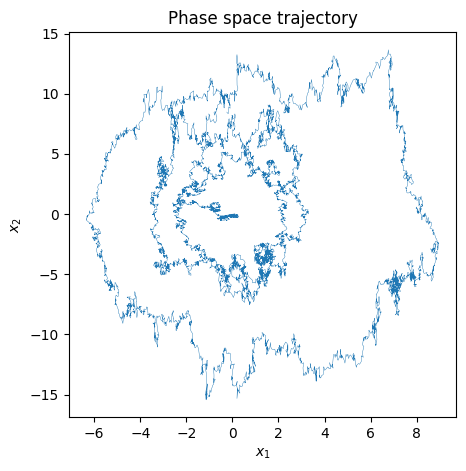

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x[:, 0], x[:, 1], lw=0.3)
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Phase space trajectory')
plt.show()

## 2. Configure and fit

In [3]:
prior_on_sd = 5.0
epsilon = 1e-5
rng2 = np.random.default_rng(99)
inducing = rng2.multivariate_normal(x.mean(0), np.cov(x, rowvar=False), size=10)

drift_kernel = ExpKernel(amplitude=5.0, length_scales=torch.tensor([2.0, 2.0]), epsilon=epsilon)
diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=prior_on_sd, target_index=1)
diff_kernel = ExpKernel(
    amplitude=diff_params['kernel_amplitude'],
    length_scales=torch.tensor([0.5, 0.5]),
    epsilon=epsilon,
)

fit = SDEVI(drift_kernel=drift_kernel, diff_kernel=diff_kernel)
res = fit.fit(
    time_series=x, sampling_period=h, inducing_points=inducing,
    v_init=diff_params['v'], target_index=1,
    max_iter=10, rel_tol=1e-5, hp_max_iter=100, verbose=False,
)
print(f'Final L = {res.lower_bound_history[-1]:.4f}')


Final L = 9733.1399


## 3. Inferred drift surface for $x_2$

The true drift on $x_2$ is $f_2(x) = -\omega^2 x_1$ — a linear restoring force in $x_1$, independent of $x_2$. With sparse-VI, finite samples, and only 10 inducing points the slope estimate is biased toward zero, but the *direction* of the restoring force is recovered.

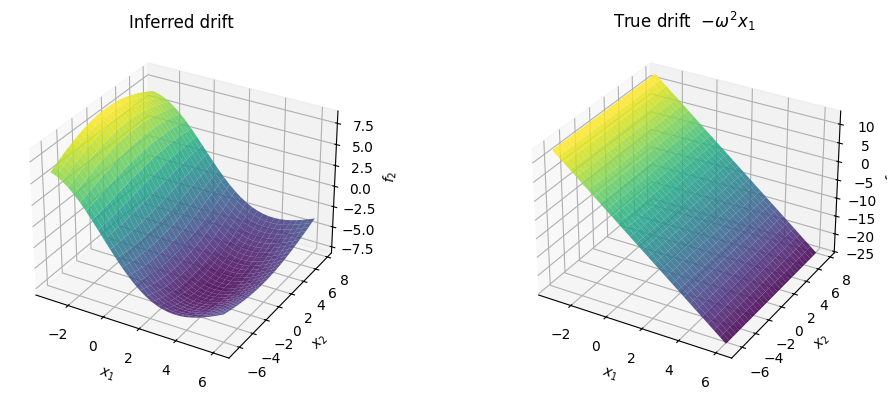

In [4]:
x1g, x2g = np.meshgrid(
    np.linspace(np.quantile(x[:,0], 0.1), np.quantile(x[:,0], 0.9), 30),
    np.linspace(np.quantile(x[:,1], 0.1), np.quantile(x[:,1], 0.9), 30),
)
grid = np.column_stack([x1g.ravel(), x2g.ravel()])
pred = predict_drift(
    kernel=drift_kernel, inducing_points=res.inducing_points,
    posterior_mean=res.f_mean, posterior_cov=res.f_cov, new_x=grid,
)
drift_surf = pred['mean'].detach().numpy().reshape(x1g.shape)
true_surf  = -omega**2 * x1g

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), subplot_kw={'projection': '3d'})
ax1.plot_surface(x1g, x2g, drift_surf, cmap='viridis', alpha=0.85)
ax1.set(xlabel='$x_1$', ylabel='$x_2$', zlabel='$f_2$', title='Inferred drift')
ax2.plot_surface(x1g, x2g, true_surf, cmap='viridis', alpha=0.85)
ax2.set(xlabel='$x_1$', ylabel='$x_2$', zlabel='$f_2$', title='True drift  $-\\omega^2 x_1$')
plt.tight_layout(); plt.show()
